In [1]:
import numpy as np
import pandas as pd
from scipy.stats import binom
import requests
import lxml.html as lx
import time
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

C:\Users\Zachary Chan\New folder\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [37]:
def get_player_data(url, year):
    
    endpoint = url + year
    result = requests.get(endpoint)
    html = lx.fromstring(result.text)

    # scrape dates of games from 2025
    date_data = html.xpath('//td[@data-stat="date_game"]/a')
    for i in date_data:
        dates_list.append(i.text)

    # scrape opponents of games from 2025
    opp_data = html.xpath('//td[@data-stat="opp_id"]/a')
    for i in opp_data:
        opp_list.append(i.text)

    # scrape home or away data from 2025
    location_data = html.xpath('//td[@data-stat="game_location"]')
    for i in location_data:
        if i.text == '@':
            location_list.append('Away')
        if i.text == None:
            location_list.append('Home')

    # scrape points of games from 2025
    point_data = html.xpath('//td[@data-stat="pts"]')
    for i in point_data:
        point_list.append(i.text)
        
    # scrape assists of games from 2025
    assist_data = html.xpath('//td[@data-stat="ast"]')
    for i in assist_data:
        assist_list.append(i.text)
        
    # scrape rebounds of games from 2025
    rebound_data = html.xpath('//td[@data-stat="trb"]')
    for i in rebound_data:
        rebound_list.append(i.text)
        
    # scrape minutes played of games from 2025
    minutes_data = html.xpath('//td[@data-stat="mp"]')
    for i in minutes_data:
        minutes_list.append(i.text)
        
    # scrape fga of games from 2025
    fga_data = html.xpath('//td[@data-stat="fga"]')
    for i in fga_data:
        fga_list.append(i.text)
        
    # scrape fg_pct of games from 2025
    fg_pct_data = html.xpath('//td[@data-stat="fg_pct"]')
    for i in fg_pct_data:
        fg_pct_list.append(i.text)
        
        
def retrieve_rows_per_game(html): 
    per_game_table = html.xpath('//table[@id="per_game-team"]//tr')
    cells = []
    for row in per_game_table: 
        # ./td|th means we start at the node (not searching the whole doc again), and choose td OR th children
        cells.append([cell.text_content() for cell in row.xpath('./td|th')]) # no text, as some cells are in <b>
    return cells


def retrieve_rows_advanced_team(html): 
    per_game_table = html.xpath('//table[@id="advanced-team"]//tr')
    cells = []
    for row in per_game_table: 
        # ./td|th means we start at the node (not searching the whole doc again), and choose td OR th children
        cells.append([cell.text_content() for cell in row.xpath('./td|th')]) # no text, as some cells are in <b>
    return cells


def retrieve_rows_standings(html): 
    per_game_table = html.xpath('//table[@id="wnba_standings"]//tr')
    cells = []
    for row in per_game_table: 
        # ./td|th means we start at the node (not searching the whole doc again), and choose td OR th children
        cells.append([cell.text_content() for cell in row.xpath('./td|th')]) # no text, as some cells are in <b>
    return cells


def get_opp_team_data(year):
    opp_team_data_list = []
    
    endpoint = 'https://www.basketball-reference.com/wnba/years/' + year + '.html'
    result = requests.get(endpoint)
    html = lx.fromstring(result.text)
    
    per_game_df = pd.DataFrame(retrieve_rows_per_game(html))
    advanced_team_df = pd.DataFrame(retrieve_rows_advanced_team(html))
    advanced_team_df = advanced_team_df[1:]
    standings_df = pd.DataFrame(retrieve_rows_standings(html))
    
    opp_team_data_list.append(per_game_df)
    opp_team_data_list.append(advanced_team_df)
    opp_team_data_list.append(standings_df)
    
    return opp_team_data_list
    
    
def clean_team_data(opp_team_data_list):
    
    # rename the dataframes for clarity
    per_game_df = opp_team_data_list[0]
    advanced_team_df = opp_team_data_list[1]
    standings_df = opp_team_data_list[2]
    
    # fix headers
    per_game_df = per_game_df.rename(columns=per_game_df.iloc[0]).loc[1:]
    advanced_team_df = advanced_team_df.rename(columns=advanced_team_df.iloc[0]).loc[1:]
    standings_df = standings_df.rename(columns=standings_df.iloc[0]).loc[1:]
    
    # remove unnessecary columns
    per_game_df.drop('Rk', axis=1, inplace=True)
    advanced_team_df.drop(['Rk', 'Arena'], axis=1, inplace=True)
    
    # merge df's
    merged_df = pd.merge(per_game_df, advanced_team_df, on='Team', how='outer')
    merged_df = pd.merge(merged_df, standings_df, on='Team', how='outer')
    
    # remove empty columns
    merged_df.drop('\xa0', axis=1, inplace=True)

    opp_team_df = merged_df
    
    return opp_team_df


def get_data(url, years):
    
    # scrape player data for all years
    for year in years:
        get_player_data(url, year)
        time.sleep(random.uniform(1, 5))
    
    # store player data in dictionary
    data_dict = {
    'Date': dates_list,
    'Opp': opp_list,
    'Location': location_list,
    'PTS': point_list,
    'AST': assist_list,
    'REB': rebound_list,
    'Min': minutes_list,
    'FGA': fga_list,
    'FG_pct': fg_pct_list
    }
    # store player data in dataframe
    player_df = pd.DataFrame(data_dict)
    
    # scrape and clean opponent team data for all years
    final_opp_team_df = pd.DataFrame()
    for year in years:
        opp_team_data_list = get_opp_team_data(year) # scrapes data
        opp_team_df = clean_team_data(opp_team_data_list) # cleans data and combine into single dataframe 'opp_team_df'
        opp_team_df['Year'] = year # record year in new column
        final_opp_team_df = pd.concat([final_opp_team_df, opp_team_df])
        time.sleep(random.uniform(1, 5))
        
    # Some columns have the duplicate names, we will rename columns for clarity
    final_opp_team_df.columns.values[39] = 'O-eFG%'
    final_opp_team_df.columns.values[40] = 'O-TOV%'
    final_opp_team_df.columns.values[41] = 'O-ORB%'
    final_opp_team_df.columns.values[42] = 'O-FT/FGA'

    final_opp_team_df.columns.values[43] = 'D-eFG%'
    final_opp_team_df.columns.values[44] = 'D-TOV%'
    final_opp_team_df.columns.values[45] = 'D-ORB%'
    final_opp_team_df.columns.values[46] = 'D-FT/FG'
    
    return player_df, final_opp_team_df


def combine_data(player_df, opp_team_df):
    cols_to_convert = opp_team_df.columns[1:-1]

    for col in cols_to_convert:
        opp_team_df[col] = pd.to_numeric(opp_team_df[col], errors='coerce')
        opp_team_df[col] = opp_team_df[col].fillna(0).astype('float')
        
    # drop wins and losses bc w/l% encompasses the statistics already
    opp_team_df.drop(columns=['W_x', 'L_x', 'W_y', 'L_y'], inplace=True)
    
    # drop 'FG', '3P', '2P', 'FT' bc they are implied by attempts/percentange
    opp_team_df.drop(columns=['FG', '3P', '2P', 'FT'], inplace=True)
    
    # drop 'TRB' bc it is implied by 'ORB' + 'DRB'
    opp_team_df.drop(columns='TRB', inplace=True)
    
    # drop 'FTr', '3PAr' bc it is implied by FTA/FGA and 3PA/FGA
    opp_team_df.drop(columns=['FTr', '3PAr'], inplace=True)
    
    # drop 'PW', 'PL', 'SOS' (unnecessary)
    opp_team_df.drop(columns=['G', 'MP', 'PW', 'PL', 'SOS'], inplace=True)
    
    # remove MOV due to its correlation with SRS
    opp_team_df.drop(columns='MOV', inplace=True)
    
    # remove SRS due to its correlation with NRtg
    opp_team_df.drop(columns='SRS', inplace=True)
    
    # remove TS% due to its correlation with other variables
    opp_team_df.drop(columns='TS%', inplace=True)
    
    # remove ORtg due to their correlation with other variables
    opp_team_df.drop(columns='ORtg', inplace=True)
    
    # remove O-eFG% due to its correlation with FG%
    opp_team_df.drop(columns='O-eFG%', inplace=True)
    
    # remove O-FT/FGA due bc it is already implied
    opp_team_df.drop(columns='O-FT/FGA', inplace=True)
    
    # remove O-ORB% due bc it is already implied
    opp_team_df.drop(columns='O-ORB%', inplace=True)
    
    # remove O-TOV% due bc it is already implied
    opp_team_df.drop(columns='O-TOV%', inplace=True)
    
    # remove D-ORB% due bc it is already implied
    opp_team_df.drop(columns='D-ORB%', inplace=True)
    
    # remove D-FT/FG due bc it is already implied
    opp_team_df.drop(columns='D-FT/FG', inplace=True)
    
    # remove STL due bc it is already implied
    opp_team_df.drop(columns='STL', inplace=True)
    
    # remove GB due bc it is already implied
    opp_team_df.drop(columns='GB', inplace=True)
    
    # remove W/L% due bc it is already implied
    opp_team_df.drop(columns='W/L%', inplace=True)
    
    dates = player_df.iloc[:, 0]
    Month = []
    for date in dates:
        m = date[5:7]
        Month.append(m)
    player_df['Month'] = Month
    
    dates = player_df.iloc[:, 0]
    Year = []
    for date in dates:
        y = date[:4]
        Year.append(y)

    player_df['Year'] = Year
    
    dtype_mapping = {
        'Date': str,
        'Opp': str, 
        'Location': str, 
        'Month': str,
        'Year': str,
        'PTS': int,
        'AST': int,
        'REB': int,
    }

    player_df = player_df.astype(dtype_mapping)
    
    # change 'Team' column to abbreviations to match the other dataframe
    abbrev = {
        'New York Liberty': 'NYL',
        'Phoenix Mercury': 'PHO',
        'Minnesota Lynx': 'MIN',
        'Atlanta Dream': 'ATL',
        'Indiana Fever': 'IND',
        'Seattle Storm': 'SEA',
        'Los Angeles Sparks': 'LAS',
        'Dallas Wings': 'DAL',
        'Las Vegas Aces': 'LVA',
        'Golden State Valkyries': 'GSV',
        'Chicago Sky': 'CHI',
        'Washington Mystics': 'WAS',
        'Connecticut Sun': 'CON',
        'New York Liberty*': 'NYL',
        'Phoenix Mercury*': 'PHO',
        'Minnesota Lynx*': 'MIN',
        'Atlanta Dream*': 'ATL',
        'Indiana Fever*': 'IND',
        'Seattle Storm*': 'SEA',
        'Los Angeles Sparks*': 'LAS',
        'Dallas Wings*': 'DAL',
        'Las Vegas Aces*': 'LVA',
        'Golden State Valkyries*': 'GSV',
        'Chicago Sky*': 'CHI',
        'Washington Mystics*': 'WAS',
        'Connecticut Sun*': 'CON',
        }

    # Replace city names with abbreviations
    opp_team_df['Team'] = opp_team_df['Team'].map(abbrev)
    
    # Rename to match other dataframe
    opp_team_df = opp_team_df.rename(columns={'Team': 'Opp'})
    
    # merge dataframes
    df = pd.merge(player_df, opp_team_df, on=['Opp', 'Year'], how='outer')
    
    # rename columns for clarity
    df = df.rename(columns={'Opp': 'Opponent',
                            'PTS_x': 'Player_PTS',
                            'AST_x': 'Player_AST',
                            'REB': 'Player_REB',
                            'MIN': 'Player_Min',
                            'FGA_x': 'Player_FGA',
                            'FG_pct': 'Player_FG%',
                            'FGA_y': 'Opp_FGA',
                            'FG%': 'Opp_FG%',
                            '3PA': 'Opp_3PA',
                            '3P%': 'Opp_3P%',
                            '2PA': 'Opp_2PA',
                            '2P%': 'Opp_2P%',
                            'FTA': 'Opp_FTA',
                            'FT%': 'Opp_FT%',
                            'ORB': 'Opp_ORB',
                            'DRB': 'Opp_DRB',
                            'AST_y': 'Opp_AST',
                            'BLK': 'Opp_BLK',
                            'TOV': 'Opp_TOV',
                            'PF': 'Opp_PF',
                            'PTS_y': 'Opp_PTS',
                            'Age': 'Opp_Age',
                            'NRtg': 'Opp_NRtg',
                            'DRtg': 'Opp_DRtg',
                            'Pace': 'Opp_Pace',
                            'D-eFG%': 'Opp_D-eFG%',
                            'D-TOV%': 'Opp_D-TOV%'})
    
    # remove empty rows
    df.dropna(subset=["Location"], inplace=True)
    
    return df


def engineer_features(df):
    
    # convert 'Date' column to datetime
    df['Date'] = pd.to_datetime(df['Date'])

    # sort by date
    df = df.sort_values('Date').reset_index(drop=True)

    # compute difference in days between consecutive games
    df['DaysSinceLastGame'] = df['Date'].diff().dt.days

    # Mark back-to-back games (1 day apart)
    df['BackToBack'] = df['DaysSinceLastGame'] == 1

    # Convert to int (1 for True, 0 for False)
    df['BackToBack'] = df['BackToBack'].astype(int)
    
    # Create the categorical column
    def categorize_days(x):
        if pd.isna(x):
            return '0'       # First game (no prior)
        elif x >= 5:
            return '5+'
        else:
            return str(int(x))  # '1' to '4'

    df['DaysSinceLastGame'] = df['Date'].diff().dt.days
    df['DaysSinceLastGame_Cat'] = df['DaysSinceLastGame'].apply(categorize_days)
    
    def convert_min_to_float(min_str):
        try:
            if pd.isna(min_str):
                return np.nan
            minutes, seconds = map(int, min_str.split(':'))
            return minutes + seconds / 60
        except:
            return np.nan

    df['Min_float'] = df['Min'].apply(convert_min_to_float)


    # Define columns to roll
    rolling_cols = {
        'Player_PTS': 'PTS_Roll5',
        'Player_AST': 'AST_Roll5',
        'Player_REB': 'REB_Roll5',
        'Min_float': 'Min_Roll5',
        'Player_FGA': 'FGA_Roll5',
        'Player_FG%': 'FGP_Roll5'
    }

    # Apply 5-game rolling average (excluding current game)
    for col, new_col in rolling_cols.items():
        df[new_col] = df[col].shift(1).rolling(window=5, min_periods=1).mean()
        
    df['PTS_ExpAvg'] = df['Player_PTS'].expanding().mean().shift(1)
    df['AST_ExpAvg'] = df['Player_AST'].expanding().mean().shift(1)
    df['REB_ExpAvg'] = df['Player_REB'].expanding().mean().shift(1)
    df['Min_ExpAvg'] = df['Min_float'].expanding().mean().shift(1)
    df['FGA_ExpAvg'] = df['Player_FGA'].expanding().mean().shift(1)
    df['FG%_ExpAvg'] = df['Player_FG%'].expanding().mean().shift(1)
    
    # create rolling points per minute
    rolling_points = df['PTS_Roll5']
    rolling_minutes = df['Min_Roll5']
    PointsPerMinute_Roll5 = [a / b for a, b in zip(rolling_points, rolling_minutes)]
    df['PointsPerMinute_Roll5'] = PointsPerMinute_Roll5
    
    # create rolling rebounds per minute
    rolling_rebounds = df['REB_Roll5']
    rolling_minutes = df['Min_Roll5']
    ReboundsPerMinute_Roll5 = [a / b for a, b in zip(rolling_rebounds, rolling_minutes)]
    df['ReboundsPerMinute_Roll5'] = ReboundsPerMinute_Roll5
    
    # create rolling assists per minute
    rolling_assists = df['AST_Roll5']
    rolling_minutes = df['Min_Roll5']
    AssistsPerMinute_Roll5 = [a / b for a, b in zip(rolling_assists, rolling_minutes)]
    df['AssistsPerMinute_Roll5'] = AssistsPerMinute_Roll5    
    
    # Define columns to roll
    rolling_cols = {
        'Player_PTS': 'PTS_Roll3',
        'Player_AST': 'AST_Roll3',
        'Player_REB': 'REB_Roll3',
        'Min_float': 'Min_Roll3',
        'Player_FGA': 'FGA_Roll3',
        'Player_FG%': 'FGP_Roll3'
    }

    # Apply 3-game rolling average (excluding current game)
    for col, new_col in rolling_cols.items():
        df[new_col] = df[col].shift(1).rolling(window=3, min_periods=1).mean()
        
    # Define columns to roll
    rolling_cols = {
        'Player_PTS': 'PTS_Roll10',
        'Player_AST': 'AST_Roll10',
        'Player_REB': 'REB_Roll10',
        'Min_float': 'Min_Roll10',
        'Player_FGA': 'FGA_Roll10',
        'Player_FG%': 'FGP_Roll10'
    }

    # Apply 3-game rolling average (excluding current game)
    for col, new_col in rolling_cols.items():
        df[new_col] = df[col].shift(1).rolling(window=10, min_periods=1).mean()
        
    # Define columns to roll
    rolling_cols = {
        'Player_PTS': 'PTS_Roll15',
        'Player_AST': 'AST_Roll15',
        'Player_REB': 'REB_Roll15',
        'Min_float': 'Min_Roll15',
        'Player_FGA': 'FGA_Roll15',
        'Player_FG%': 'FGP_Roll15'
    }

    # Apply 5-game rolling average (excluding current game)
    for col, new_col in rolling_cols.items():
        df[new_col] = df[col].shift(1).rolling(window=15, min_periods=1).mean()
        
    # Define columns to roll
    rolling_cols = {
        'Player_PTS': 'PTS_Roll20',
        'Player_AST': 'AST_Roll20',
        'Player_REB': 'REB_Roll20',
        'Min_float': 'Min_Roll20',
        'Player_FGA': 'FGA_Roll20',
        'Player_FG%': 'FGP_Roll20'
    }

    # Apply 5-game rolling average (excluding current game)
    for col, new_col in rolling_cols.items():
        df[new_col] = df[col].shift(1).rolling(window=20, min_periods=1).mean()
        
    df['Minutes_x_FGA'] = df['Min_Roll5'] * df['FGA_Roll5']
    df['Hot_Streak_PTS'] = (df['PTS_Roll5'] > df['PTS_Roll10']).astype(int)
    df['Hot_Streak_REB'] = (df['REB_Roll5'] > df['REB_Roll10']).astype(int)
    df['Hot_Streak_AST'] = (df['AST_Roll5'] > df['AST_Roll10']).astype(int)
    df['PTS_LastGame'] = df['Player_PTS'].shift(1)
    df['Min_LastGame'] = df['Min_float'].shift(1)
        
    return df


def train_xgb_model(df, target_column, categorical_features, numeric_features):

    # Drop rows with missing values
    all_features = categorical_features + numeric_features + [target_column]
    df_clean = df[all_features].dropna()

    X = df_clean[categorical_features + numeric_features]
    y = df_clean[target_column]

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(drop='first'), categorical_features)
        ],
        remainder='passthrough'
    )

    # Fit preprocessor separately to get feature names
    preprocessor.fit(X_train)
    X_train_transformed = preprocessor.transform(X_train)

    # Get transformed feature names
    ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
    all_transformed_features = np.concatenate([ohe_feature_names, numeric_features])

    # Fit model directly (not inside pipeline to avoid feature name mismatch)
    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.8,
        random_state=42,
        objective='reg:squarederror'
    )

    model.fit(X_train_transformed, y_train)

    # Evaluate
    X_test_transformed = preprocessor.transform(X_test)
    y_pred = model.predict(X_test_transformed)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Feature importances
    importances = model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': all_transformed_features,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    return rmse, r2, feature_importance_df


def tune_xgb_model(df, target_column, categorical_features, numeric_features):
    # Split data
    X = df[categorical_features + numeric_features]
    y = df[target_column]

    # Preprocessing
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
            ('num', StandardScaler(), numeric_features)
        ]
    )

    # Define base model
    xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

    # Define full pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', xgb)
    ])

    # Grid of hyperparameters
    param_grid = {
        'regressor__n_estimators': [100, 200],
        'regressor__max_depth': [3, 5, 7],
        'regressor__learning_rate': [0.01, 0.1],
        'regressor__subsample': [0.8, 1.0],
        'regressor__colsample_bytree': [0.8, 1.0]
    }

    # Grid search
    grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='neg_root_mean_squared_error', verbose=1, n_jobs=-1)
    grid_search.fit(X, y)

    # Best model
    best_model = grid_search.best_estimator_
    print("Best parameters:", grid_search.best_params_)

    # Predict and evaluate
    y_pred = best_model.predict(X)
    rmse = mean_squared_error(y, y_pred, squared=False)
    r2 = r2_score(y, y_pred)
    
    #y_pred = model.predict(X_test)
    plot = plot_actual_vs_predicted(y, y_pred)

    return best_model, rmse, r2, plot


def plot_actual_vs_predicted(y_test, y_pred, title="Actual vs Predicted Points"):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, edgecolor=None)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', label="Perfect Prediction")
    
    # Add regression line
    sns.regplot(x=y_test, y=y_pred, scatter=False, color='blue', label='Fit Line')

    plt.xlabel("Actual Points")
    plt.ylabel("Predicted Points")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    return plt.show()


def predict_future_game(model, future_data):

    # If input is a single game dict, convert to DataFrame
    if isinstance(future_data, dict):
        future_df = pd.DataFrame([future_data])
    elif isinstance(future_data, pd.DataFrame):
        future_df = future_data.copy()
    else:
        raise ValueError("Input must be a dict or DataFrame")
    
    # Ensure categorical columns are strings (XGBoost handles them this way if encoded)
    for col in categorical:
        future_df[col] = future_df[col].astype(str)
    
    # Make sure all required columns are present
    expected_cols = categorical + numerical
    missing_cols = set(expected_cols) - set(future_df.columns)
    if missing_cols:
        raise ValueError(f"Missing required features: {missing_cols}")

    # Predict
    preds = model.predict(future_df[expected_cols])
    return pd.Series(preds, name="Predicted_PTS")

In [75]:
dates_list = []
opp_list = []
location_list = []
point_list = []
assist_list = []
rebound_list = []
fga_list = []
fg_pct_list = []
minutes_list = []


url = 'https://www.basketball-reference.com/wnba/players/r/reesean01w/gamelog/'
years = ['2025','2024']

player_df, opp_team_df = get_data(url, years)

In [76]:
df = combine_data(player_df, opp_team_df)

In [77]:
df = engineer_features(df)

## Points

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters: {'regressor__colsample_bytree': 0.8, 'regressor__learning_rate': 0.01, 'regressor__max_depth': 5, 'regressor__n_estimators': 100, 'regressor__subsample': 0.8}


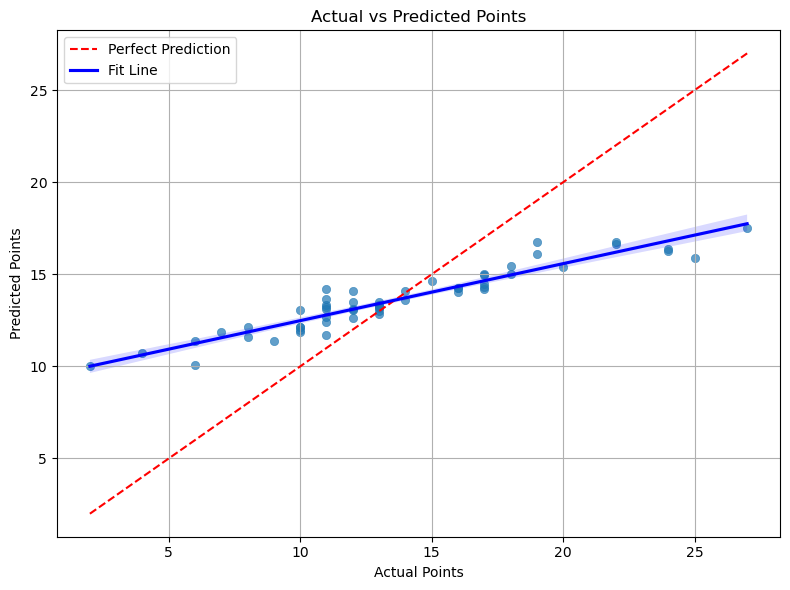

Test RMSE: 3.60
Test R² Score: 0.51


In [78]:
categorical = ['Year', 'BackToBack', 'Location']
numerical = ['PTS_Roll5', 'Min_Roll5']

best_model, rmse, r2, plot = tune_xgb_model(df, target_column='Player_PTS',
                                  categorical_features=categorical,
                                  numeric_features=numerical)

print(f"Test RMSE: {rmse:.2f}")
print(f"Test R² Score: {r2:.2f}")

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters: {'regressor__colsample_bytree': 0.8, 'regressor__learning_rate': 0.01, 'regressor__max_depth': 3, 'regressor__n_estimators': 100, 'regressor__subsample': 0.8}


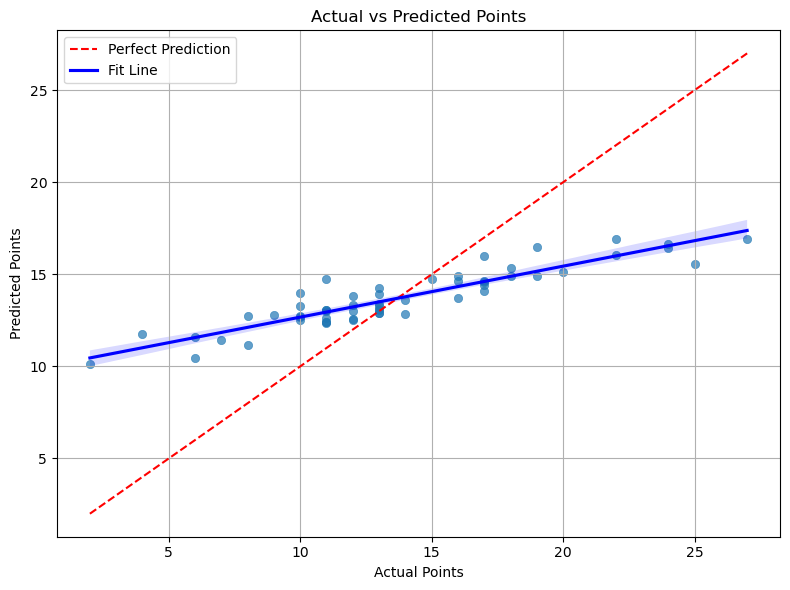

RMSE: 3.78
R² Score: 0.46


In [79]:
categorical = ['Year', 'BackToBack', 'Location', 'Month']
numerical = ['PTS_Roll5', 'PTS_Roll10', 'PTS_Roll15', 'Min_Roll3', 'Min_Roll10', 'FGA_Roll3', 'FGA_Roll10', 'PTS_Roll3', 
             'PointsPerMinute_Roll5', 'Opp_D-TOV%', 'Opp_DRtg', 'Opp_Pace', 'Opp_DRB', 'Opp_BLK', 'Opp_PF', 'Opp_TOV', 
             'Opp_D-eFG%']

best_model, rmse, r2, plot = tune_xgb_model(df, target_column='Player_PTS',
                                      categorical_features=categorical,
                                      numeric_features=numerical)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")
plot

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters: {'regressor__colsample_bytree': 0.8, 'regressor__learning_rate': 0.01, 'regressor__max_depth': 3, 'regressor__n_estimators': 100, 'regressor__subsample': 0.8}


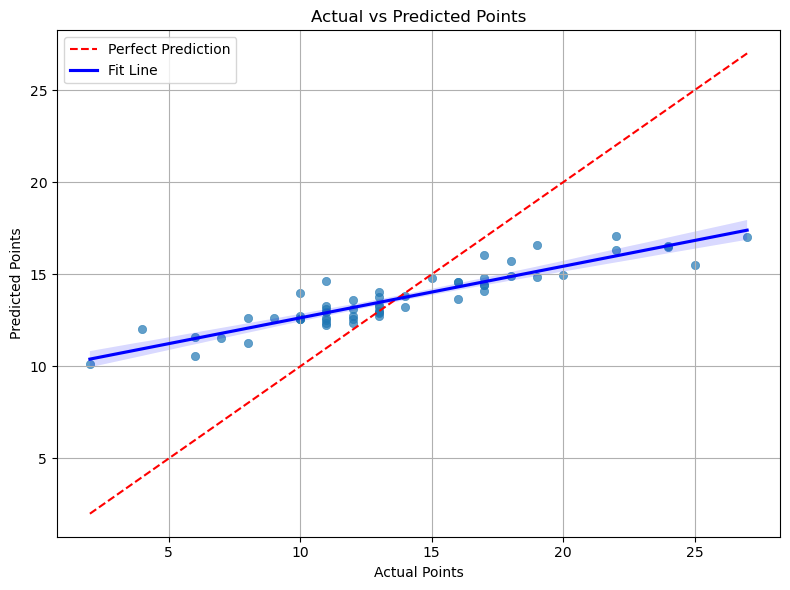

RMSE: 3.76
R² Score: 0.47


In [82]:
categorical = ['Year', 'BackToBack', 'Location', 'Month']
numerical = ['PTS_Roll5', 'PTS_Roll10', 'PTS_Roll15', 'Min_Roll3', 'Min_Roll10', 'FGA_Roll3', 'FGA_Roll10', 'PTS_Roll3', 
             'PointsPerMinute_Roll5', 'Opp_D-TOV%', 'Opp_DRtg', 'Opp_Pace', 'Opp_DRB', 'Opp_BLK', 'Opp_PF', 'Opp_TOV', 
             'Opp_D-eFG%', 'Minutes_x_FGA']

best_model, rmse, r2, plot = tune_xgb_model(df, target_column='Player_PTS',
                                      categorical_features=categorical,
                                      numeric_features=numerical)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")
plot

In [ ]:
future_df = pd.dataf

preds = best_model.predict(future_df)

In [457]:
categorical + numerical

['Year',
 'BackToBack',
 'Location',
 'Month',
 'Hot_Streak',
 'PTS_Roll5',
 'PTS_Roll10',
 'PTS_Roll15',
 'Min_Roll3',
 'Min_Roll10',
 'FGA_Roll3',
 'FGA_Roll10',
 'PTS_Roll3',
 'PointsPerMinute_Roll5',
 'Opp_D-TOV%',
 'Opp_DRtg',
 'Opp_Pace',
 'Opp_DRB',
 'Opp_BLK',
 'Opp_PF',
 'Opp_TOV',
 'Opp_D-eFG%',
 'Minutes_x_FGA']

In [304]:
df.columns

Index(['Date', 'Opponent', 'Location', 'Player_PTS', 'Player_AST',
       'Player_REB', 'Min', 'Player_FGA', 'Player_FG%', 'Month', 'Year',
       'Opp_FGA', 'Opp_FG%', 'Opp_3PA', 'Opp_3P%', 'Opp_2PA', 'Opp_2P%',
       'Opp_FTA', 'Opp_FT%', 'Opp_ORB', 'Opp_DRB', 'Opp_AST', 'Opp_BLK',
       'Opp_TOV', 'Opp_PF', 'Opp_PTS', 'Opp_Age', 'Opp_DRtg', 'Opp_NRtg',
       'Opp_Pace', 'Opp_D-eFG%', 'Opp_D-TOV%', 'DaysSinceLastGame',
       'BackToBack', 'DaysSinceLastGame_Cat', 'Min_float', 'PTS_Roll5',
       'AST_Roll5', 'REB_Roll5', 'Min_Roll5', 'FGA_Roll5', 'FGP_Roll5',
       'PTS_ExpAvg', 'AST_ExpAvg', 'REB_ExpAvg', 'Min_ExpAvg', 'FGA_ExpAvg',
       'FG%_ExpAvg', 'PointsPerMinute_Roll5', 'PTS_Roll3', 'AST_Roll3',
       'REB_Roll3', 'Min_Roll3', 'FGA_Roll3', 'FGP_Roll3', 'PTS_Roll10',
       'AST_Roll10', 'REB_Roll10', 'Min_Roll10', 'FGA_Roll10', 'FGP_Roll10',
       'PTS_Roll15', 'AST_Roll15', 'REB_Roll15', 'Min_Roll15', 'FGA_Roll15',
       'FGP_Roll15', 'PTS_Roll20', 'AST_Roll20', 'RE

In [20]:
numeric_df = df.select_dtypes(include=np.number)

title_list = []
corr_list = []
for i in numeric_df.columns:
    corr = numeric_df[i].corr(numeric_df['Player_PTS'])
    corr_list.append(corr)
    title = i + ', Player_PTS'
    title_list.append(title)
    
corr_df = pd.DataFrame()
corr_df['Features'] = title_list
corr_df['Corr'] = corr_list
corr_df.head(50)

,Features,Corr
0,"Player_PTS, Player_PTS",1.000000
1,"Player_AST, Player_PTS",0.337947
2,"Player_REB, Player_PTS",0.105007
3,"Opp_FGA, Player_PTS",0.090818
4,"Opp_FG%, Player_PTS",0.099362
5,"Opp_3PA, Player_PTS",-0.173852
6,"Opp_3P%, Player_PTS",0.055065
7,"Opp_2PA, Player_PTS",0.177632
8,"Opp_2P%, Player_PTS",-0.053463
9,"Opp_FTA, Player_PTS",-0.066861


In [317]:
corr_df.tail(15)

,Features,Corr
49,"Min_Roll10, Player_PTS",0.184031
50,"FGA_Roll10, Player_PTS",0.221445
51,"FGP_Roll10, Player_PTS",0.097110
52,"PTS_Roll15, Player_PTS",0.130510
53,"AST_Roll15, Player_PTS",-0.016045
54,"REB_Roll15, Player_PTS",-0.089127
55,"Min_Roll15, Player_PTS",0.168503
56,"FGA_Roll15, Player_PTS",0.204461
57,"FGP_Roll15, Player_PTS",0.075198
58,"PTS_Roll20, Player_PTS",0.108279


In [441]:
df

,Date,Opponent,Location,Player_PTS,Player_AST,Player_REB,Min,Player_FGA,Player_FG%,Month,...,PTS_Roll20,AST_Roll20,REB_Roll20,Min_Roll20,FGA_Roll20,FGP_Roll20,Minutes_x_FGA,Hot_Streak,PTS_LastGame,Min_LastGame
0,2020-07-25,NYL,Home,18.0,2.0,8.0,28:05,12,.500,07,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN
1,2020-07-28,MIN,Home,18.0,3.0,10.0,29:36,10,.500,07,...,18.0,2.000000,8.000000,28.083333,12.00,0.500000,337.000000,0,18.0,28.083333
2,2020-07-30,WAS,Home,15.0,3.0,10.0,27:18,14,.357,07,...,18.0,2.500000,9.000000,28.841667,11.00,0.500000,317.258333,0,18.0,29.600000
3,2020-08-01,LAS,Home,21.0,5.0,9.0,34:17,15,.533,08,...,17.0,2.666667,9.333333,28.327778,12.00,0.452333,339.933333,0,15.0,27.300000
4,2020-08-04,CON,Home,22.0,3.0,5.0,31:50,16,.500,08,...,18.0,3.250000,9.250000,29.816667,12.75,0.472500,380.162500,0,21.0,34.283333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,2025-07-03,LAS,Home,17.0,4.0,14.0,37:26,18,.389,07,...,20.6,3.250000,6.500000,30.506667,13.75,0.504950,571.428000,1,21.0,34.083333
177,2025-07-06,SEA,Home,8.0,3.0,6.0,35:07,17,.235,07,...,20.9,3.250000,7.000000,31.232500,14.35,0.499400,579.193333,0,17.0,37.433333
178,2025-07-08,LVA,Home,15.0,5.0,7.0,36:30,14,.286,07,...,19.4,3.350000,6.400000,31.171667,13.85,0.488950,595.226667,0,8.0,35.116667
179,2025-07-13,ATL,Home,18.0,4.0,10.0,37:12,19,.368,07,...,19.4,3.550000,6.250000,31.715000,13.85,0.481800,557.706667,0,15.0,36.500000


## Rebounds

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters: {'regressor__colsample_bytree': 0.8, 'regressor__learning_rate': 0.01, 'regressor__max_depth': 3, 'regressor__n_estimators': 100, 'regressor__subsample': 0.8}


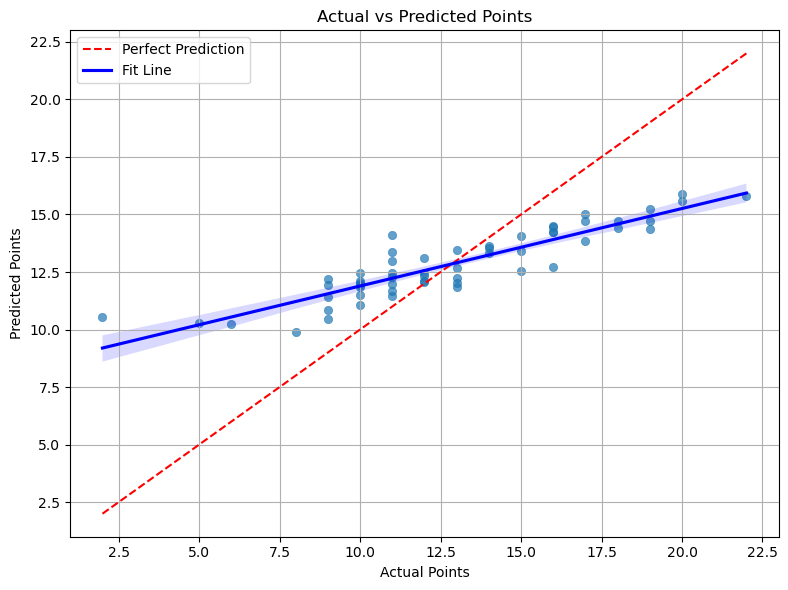

RMSE: 2.71
R² Score: 0.53


In [86]:
categorical = ['Year', 'Location']
numerical = ['REB_Roll5', 'REB_Roll10', 'REB_Roll15', 'Min_Roll3', 'Min_Roll10', 'REB_Roll3']

best_model, rmse, r2, plot = tune_xgb_model(df, target_column='Player_REB',
                                      categorical_features=categorical,
                                      numeric_features=numerical)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")
plot

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters: {'regressor__colsample_bytree': 1.0, 'regressor__learning_rate': 0.01, 'regressor__max_depth': 3, 'regressor__n_estimators': 100, 'regressor__subsample': 0.8}


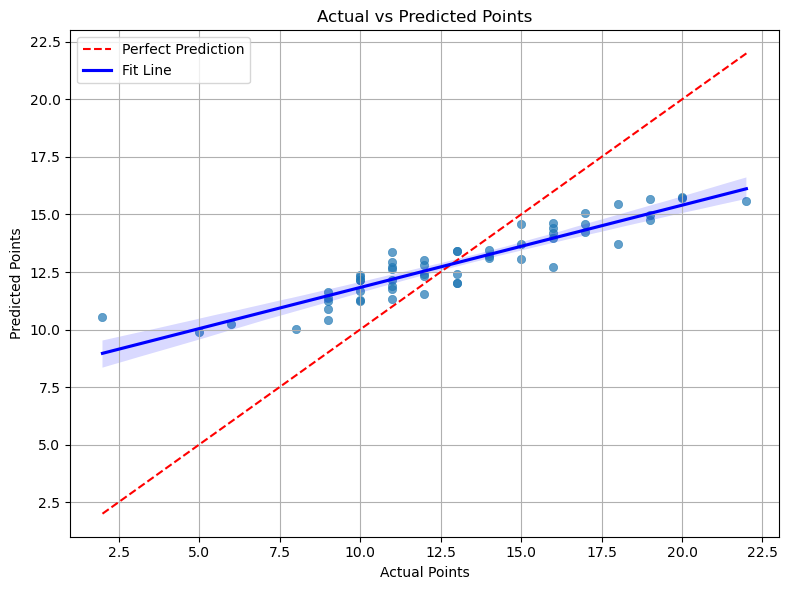

RMSE: 2.62
R² Score: 0.56


In [89]:
categorical = ['Year', 'BackToBack', 'Location', 'Month']
numerical = ['REB_Roll5', 'REB_Roll10', 'REB_Roll15', 'Min_Roll3', 'Min_Roll10', 'REB_Roll3', 'FGA_Roll5',
             'ReboundsPerMinute_Roll5', 'Opp_Pace', 'Opp_DRB', 'Opp_ORB', 'Opp_PF', 'Opp_TOV',
             'Opp_D-eFG%', 'Opp_DRtg', 'Opp_NRtg', 'Opp_D-TOV%',
             'Opp_3PA', 'Opp_2PA', 'Opp_FTA', 'Opp_3P%', 'Opp_2P%', 'Opp_FT%']

best_model, rmse, r2, plot = tune_xgb_model(df, target_column='Player_REB',
                                      categorical_features=categorical,
                                      numeric_features=numerical)

print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")
plot

In [70]:
title_list = []
corr_list = []
for i in numeric_df.columns:
    corr = numeric_df[i].corr(numeric_df['Player_REB'])
    corr_list.append(corr)
    title = i + ', Player_REB'
    title_list.append(title)
    
corr_df = pd.DataFrame()
corr_df['Features'] = title_list
corr_df['Corr'] = corr_list
corr_df.head(50)

,Features,Corr
0,"Player_PTS, Player_REB",0.105007
1,"Player_AST, Player_REB",0.272398
2,"Player_REB, Player_REB",1.000000
3,"Opp_FGA, Player_REB",-0.032053
4,"Opp_FG%, Player_REB",-0.051332
5,"Opp_3PA, Player_REB",0.200058
6,"Opp_3P%, Player_REB",0.163795
7,"Opp_2PA, Player_REB",-0.181785
8,"Opp_2P%, Player_REB",0.007451
9,"Opp_FTA, Player_REB",-0.286478
